# Parsing de Fechas

En este JNB se revisará el tema de Parsing de Fechas.

In [5]:
# modules we'll use
import pandas as pd
import numpy as np
import seaborn as sns
import datetime

# read in our data
landslides = pd.read_csv("https://media.githubusercontent.com/media/GTD2401-ACD-GA-EJ26/ACD.datasets.kaggle/refs/heads/main/catalog.csv")

# set seed for reproducibility
np.random.seed(0)

¡Esta es una de las habilidades más valiosas en Python! Trabajar con fechas puede ser un dolor de cabeza si no se transforman correctamente, porque para Python, una fecha escrita como "02/03/07" es solo una cadena de texto (un string), no un objeto con el que pueda hacer cálculos.

Aquí tienes la traducción y una explicación de los conceptos clave:

Trabajando con Fechas en Python
En este notebook, vamos a trabajar con fechas. ¡Comencemos!

1. Configuración del entorno
Lo primero es cargar las librerías y el conjunto de datos. Usaremos un dataset de deslizamientos de tierra (landslides) ocurridos entre 2007 y 2016.

Python
import pandas as pd
import numpy as np
import seaborn as sns
import datetime

# Leer los datos
landslides = pd.read_csv("../input/landslide-events/catalog.csv")
np.random.seed(0)
2. Verificar el tipo de dato de la columna de fecha
Al revisar las primeras filas con landslides['date'].head(), vemos fechas, pero Pandas nos indica que el tipo de dato (dtype) es "object".

¿Qué significa "object"? En Pandas, esto generalmente significa que la columna contiene cadenas de texto (strings).

¿Por qué es un problema? Si es un texto, no puedes pedirle a Python que te diga "qué día de la semana fue" o "cuántos meses pasaron entre dos fechas". Necesitamos el tipo de dato datetime64.

3. Convertir columnas a formato datetime (Parsing Dates)
Este proceso se llama "parsing" (analizar gramaticalmente) porque tomamos un texto y lo descomponemos en sus partes: día, mes y año. Usamos los formatos strftime:

%d: Día.

%m: Mes.

%y: Año de dos dígitos (ej. 07).

%Y: Año de cuatro dígitos (ej. 2007).


In [12]:
landslides['date_parsed'] = pd.to_datetime(landslides['date'], format="%m/%d/%y")

4. Seleccionar el día del mes
Una vez que la columna es tipo datetime64, podemos usar el accesor .dt para extraer información específica, como el día:

In [13]:
# Extraer solo el día
day_of_month_landslides = landslides['date_parsed'].dt.day

Si intentas hacer esto con la columna original (la que era tipo "object"), Python te dará un error porque no sabe cómo extraer un "día" de una simple cadena de texto.

5. Graficar para verificar
Una excelente forma de saber si procesamos bien las fechas es crear un histograma de los días del mes.

Esperamos: Valores entre 1 y 31.

La lógica: Los deslizamientos deberían distribuirse de forma más o menos uniforme en todos los días, con un pequeño descenso en el día 31 (porque no todos los meses lo tienen).


<Axes: xlabel='date_parsed', ylabel='Count'>

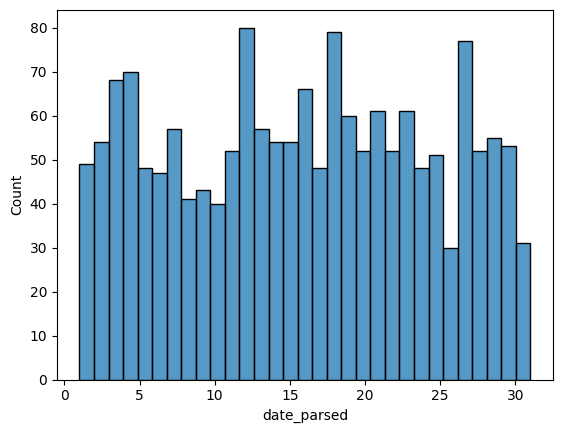

In [14]:
# Eliminar nulos y graficar
day_of_month_landslides = day_of_month_landslides.dropna()
sns.histplot(day_of_month_landslides, kde=False, bins=31)